In [1]:
import json
from datetime import datetime, timezone
from json import dumps

import numpy as np
import pandas as pd
from dotenv import dotenv_values
from pymongo import MongoClient
# from sentence_transformers import SentenceTransformer


In [2]:
# 1. Chargement ciblé des variables d'environnement
env_local_vars = dotenv_values(".env.local")
local_uri = env_local_vars.get("LOCAL_URI")
# model_embed = SentenceTransformer("all-MiniLM-L6-v2")

# 2. Test de la connexion locale
try:
    if not local_uri:
        raise ValueError("LOCAL_URI non trouvé dans .env.local")
    client = MongoClient(local_uri, serverSelectionTimeoutMS=5000)
    client.admin.command("ping")
    db = client["securite_routiere"]
    print("Connexion locale établie avec succès")
except Exception as e:
    print(f"Erreur de connexion locale : {e}")

Connexion locale établie avec succès


In [3]:
# Chargement des fichiers CSV (ou récupération depuis les collections brutes)
df_caract = pd.read_csv("datasets/2024/caracteristiques-2024.csv", sep=";", low_memory=False)
df_lieux = pd.read_csv("datasets/2024/lieux-2024.csv", sep=";", low_memory=False)
df_vehicules = pd.read_csv("datasets/2024/vehicules-2024.csv", sep=";", low_memory=False)
df_usagers = pd.read_csv("datasets/2024/usagers-2024.csv", sep=";", low_memory=False)

# Remplacement des valeurs NaN par None (converti en null dans MongoDB)
for df in [df_caract, df_lieux, df_vehicules, df_usagers]:
    df.replace({np.nan: None}, inplace=True)

# Nettoyage et préparation des données caractéristiques
def parse_date(row):
    try:
        if pd.isna(row.get("an")) or pd.isna(row.get("mois")) or pd.isna(row.get("jour")):
            return None

        # Conversion sécurisée de an, mois, jour
        an = int(float(row["an"]))
        mois = int(float(row["mois"]))
        jour = int(float(row["jour"]))

        # Gestion de l'heure et des minutes
        hrmn_raw = row.get("hrmn")
        hour, minute = 0, 0
        
        if hrmn_raw is not None and not pd.isna(hrmn_raw):
            hrmn_str = str(hrmn_raw).strip()
            hrmn_str = hrmn_str.removesuffix(".0")

            if ":" in hrmn_str:
                parts = hrmn_str.split(":")
                hour = int(parts[0])
                minute = int(parts[1])
            elif hrmn_str.isdigit():
                hrmn_str = hrmn_str.zfill(4)
                hour = int(hrmn_str[:2])
                minute = int(hrmn_str[2:])

        # timezone.utc directement accessible via l'import
        return datetime(an, mois, jour, hour, minute, tzinfo=timezone.utc)
    except Exception as e:
        return None

def parse_coord(val):
    if val is None or pd.isna(val):
        return None
    try:
        return float(str(val).replace(",", "."))
    except (ValueError, TypeError):
        return None

# def generer_resume_accident(doc):
#     """Traduit les données de l'accident en texte descriptif."""
#     date_str = doc.get("hrmn", "")
#     commune = doc.get("com", "inconnue")
#     dep = doc.get("dep", "")
    
#     nb_vehicules = len(doc.get("vehicules", []))
#     nb_usagers = sum(len(v.get("usagers", [])) for v in doc.get("vehicules", []))
    
#     # Construction du texte narratif
#     texte = (
#         f"Accident survenu dans le département {dep} (commune {commune}) à {date_str}. "
#         f"Nombre de véhicules impliqués : {nb_vehicules}, total d'usagers : {nb_usagers}. "
#         f"Type de collision : code {doc.get('col')}, météo : code {doc.get('atm')}, luminosité : code {doc.get('lum')}. "
#         f"Voie : {doc.get('lieu', {}).get('voie', 'non précisée')}, surface de la route : {doc.get('lieu', {}).get('surf')}."
#     )
#     return texte

df_caract["date"] = df_caract.apply(parse_date, axis=1)
df_caract["lat_clean"] = df_caract["lat"].apply(parse_coord)
df_caract["long_clean"] = df_caract["long"].apply(parse_coord)

In [4]:

# Structuration hiérarchique : Usagers -> Véhicules -> Accidents
# A. Dictionnaire des Usagers indexé par id_vehicule
usagers_by_vehicule = {}
cols_usager = [
    "id_usager", "place", "catu", "grav", "sexe", "An_nais",
    "trajet", "secu1", "secu2", "secu3", "locp", "actp", "etatp"
]

# Prise en compte du format secu1-3 si déjà agrégé
if "secu1-3" in df_usagers.columns:
    cols_usager = ["id_usager", "place", "catu", "grav", "sexe", "An_nais", "trajet", "secu1-3", "locp", "actp", "etatp"]

for row in df_usagers.to_dict(orient="records"):
    id_v = row.get("id_vehicule")
    doc_usager = {k: row[k] for k in cols_usager if k in row and row[k] is not None}
    usagers_by_vehicule.setdefault(id_v, []).append(doc_usager)

# B. Dictionnaire des Véhicules indexé par Num_Acc
vehicules_by_acc = {}
cols_vehicule = [
    "id_vehicule", "Num_Veh", "senc", "catv", "obs",
    "obsm", "choc", "manv", "motor", "occutc"
]

for row in df_vehicules.to_dict(orient="records"):
    num_acc = row.get("Num_Acc")
    id_v = row.get("id_vehicule")
    doc_vehicule = {k: row[k] for k in cols_vehicule if k in row and row[k] is not None}
    doc_vehicule["usagers"] = usagers_by_vehicule.get(id_v, [])
    vehicules_by_acc.setdefault(num_acc, []).append(doc_vehicule)

# C. Dictionnaire des Lieux indexé par Num_Acc
cols_lieu = [
    "catr", "voie", "V1", "V2", "circ", "nbv", "vosp", "prof",
    "pr", "pr1", "plan", "larrout", "surf", "infra", "situ", "vma"
]

lieux_by_acc = {}
for row in df_lieux.to_dict(orient="records"):
    num_acc = row.get("Num_Acc")
    doc_lieu = {k: row[k] for k in cols_lieu if k in row and row[k] is not None}
    lieux_by_acc[num_acc] = doc_lieu

# D. Construction finale des documents Accidents
cols_caract_env = ["adr", "dep", "com", "agg", "int", "atm", "lum", "col"]
accidents_docs = []

# Conversion coordonnées en GeoJSON
for row in df_caract.to_dict(orient="records"):
    if row.get("long_clean") is not None and row.get("lat_clean") is not None:
        geojson_location = {
            "type": "Point",
            "coordinates": [row.get("long_clean"), row.get("lat_clean")]
        }
    else:
        geojson_location = None

    num_acc = row.get("Num_Acc")
    doc_accident = {
        "Num_Acc": num_acc,
        "date": row.get("date"),
        "jour": row.get("jour"),
        "mois": row.get("mois"),
        "an": row.get("an"),
        "hrmn": str(row.get("hrmn")),
        "localisation": geojson_location,
        "lieu": lieux_by_acc.get(num_acc, {}),
        "vehicules": vehicules_by_acc.get(num_acc, [])
    }
    
    for k in cols_caract_env:
        if k in row and row[k] is not None:
            doc_accident[k] = row[k]
            
    accidents_docs.append(doc_accident)

# écriture dans MongoDB
col_accidents = db["accidents"]
col_accidents.drop()

if accidents_docs:
    # print("1. Génération des résumés textuels...")
    # textes = [generer_resume_accident(doc) for doc in accidents_docs]

    # print("2. Calcul des embeddings (vectorisation par lot)...")
    # vecteurs = model_embed.encode(textes, batch_size=64, show_progress_bar=True).tolist()

    # print("3. Ajout des champs aux documents...")
    # for i, doc in enumerate(accidents_docs):
    #     doc["resume_texte"] = textes[i]
    #     doc["embedding"] = vecteurs[i]

    print("Ingestion dans MongoDB...")
    col_accidents.insert_many(accidents_docs)
    
    # Création des index
    col_accidents.create_index("Num_Acc", unique=True)
    col_accidents.create_index("dep")
    col_accidents.create_index([("localisation", "2dsphere")])
    
    print(f"Succès : {len(accidents_docs)} accidents enrichis et insérés.")

Ingestion dans MongoDB...
Succès : 54402 accidents enrichis et insérés.


In [5]:
pipeline_weekend_mortalite = [
    {"$unwind": "$vehicules"},
    {"$unwind": "$vehicules.usagers"},
    {
        "$project": {
            "heure": {"$hour": "$date"},
            "jour_semaine": {"$dayOfWeek": "$date"},  # 1 = Dimanche, 7 = Samedi
            "est_tue": {"$cond": [{"$eq": ["$vehicules.usagers.grav", 2]}, 1, 0]}
        }
    },
    {
        "$project": {
            "heure": 1,
            "est_tue": 1,
            "periode": {
                "$cond": [
                    {"$in": ["$jour_semaine", [1, 7]]},
                    "Week-end (Sam-Dim)",
                    "Semaine (Lun-Ven)"
                ]
            }
        }
    },
    {
        "$group": {
            "_id": {"periode": "$periode", "heure": "$heure"},
            "total_usagers": {"$sum": 1},
            "total_morts": {"$sum": "$est_tue"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "periode": "$_id.periode",
            "heure": "$_id.heure",
            "taux_mortalite_pct": {
                "$multiply": [{"$divide": ["$total_morts", "$total_usagers"]}, 100]
            }
        }
    },
    {"$sort": {"heure": 1}}
]

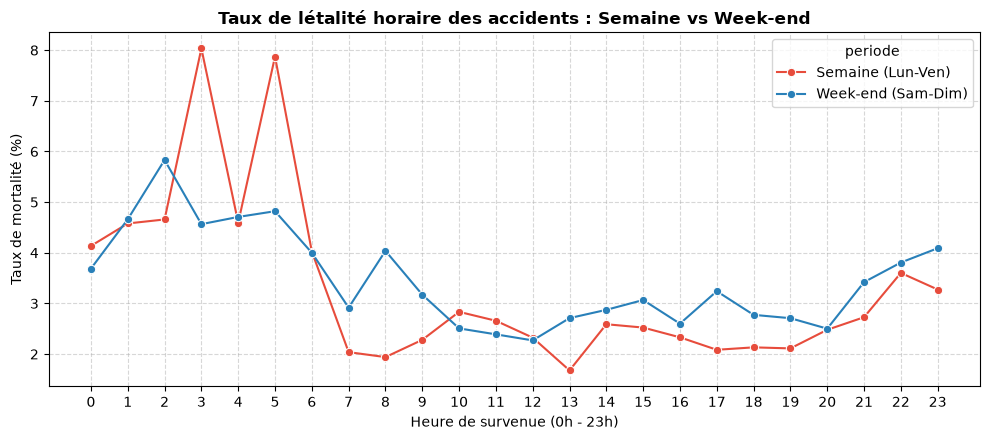

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

df_q1 = pd.DataFrame(list(db["accidents"].aggregate(pipeline_weekend_mortalite)))

plt.figure(figsize=(10, 4.5))
sns.lineplot(
    data=df_q1, 
    x="heure", 
    y="taux_mortalite_pct", 
    hue="periode", 
    marker="o",
    palette=["#E74C3C", "#2980B9"]
)
plt.title("Taux de létalité horaire des accidents : Semaine vs Week-end", fontsize=12, fontweight="bold")
plt.xlabel("Heure de survenue (0h - 23h)")
plt.ylabel("Taux de mortalité (%)")
plt.xticks(range(0, 24))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [9]:
pipeline_vulnerabilite = [
    {"$unwind": "$vehicules"},
    {"$unwind": "$vehicules.usagers"},
    {
        "$project": {
            "catu": "$vehicules.usagers.catu",  # 1=Conducteur, 2=Passager, 3=Piéton
            "catv": "$vehicules.catv",
            "grav": "$vehicules.usagers.grav",
            "est_grave": {
                "$cond": [{"$in": ["$vehicules.usagers.grav", [2, 3]]}, 1, 0] # 2=Tué, 3=Hospitalisé
            }
        }
    },
    {
        "$project": {
            "est_grave": 1,
            "role_usager": {
                "$switch": {
                    "branches": [
                        {"case": {"$eq": ["$catu", 1]}, "then": "Conducteur"},
                        {"case": {"$eq": ["$catu", 2]}, "then": "Passager"},
                        {"case": {"$eq": ["$catu", 3]}, "then": "Piéton"}
                    ],
                    "default": "Non précisé"
                }
            },
            "mode_transport": {
                "$switch": {
                    "branches": [
                        {"case": {"$eq": ["$catu", 3]}, "then": "Piéton"},
                        {"case": {"$eq": ["$catv", 1]}, "then": "Vélo"},
                        {"case": {"$in": ["$catv", [30, 31, 32, 33, 34]]}, "then": "Deux-roues motorisé"},
                        {"case": {"$eq": ["$catv", 7]}, "then": "Voiture légère"}
                    ],
                    "default": "Autre"
                }
            }
        }
    },
    {"$match": {"role_usager": {"$ne": "Non précisé"}, "mode_transport": {"$ne": "Autre"}}},
    {
        "$group": {
            "_id": {"role_usager": "$role_usager", "mode_transport": "$mode_transport"},
            "total_victimes": {"$sum": 1},
            "total_graves": {"$sum": "$est_grave"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "role_usager": "$_id.role_usager",
            "mode_transport": "$_id.mode_transport",
            "taux_gravite_pct": {
                "$multiply": [{"$divide": ["$total_graves", "$total_victimes"]}, 100]
            }
        }
    }
]

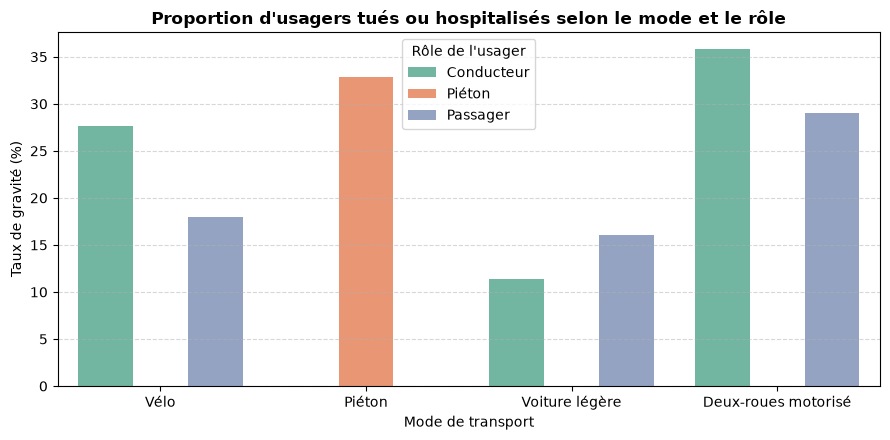

In [12]:
df_q2 = pd.DataFrame(list(db["accidents"].aggregate(pipeline_vulnerabilite)))

if not df_q2.empty:
    plt.figure(figsize=(9, 4.5))
    sns.barplot(
        data=df_q2,
        x="mode_transport",
        y="taux_gravite_pct",
        hue="role_usager",
        palette="Set2"
    )
    plt.title("Proportion d'usagers tués ou hospitalisés selon le mode et le rôle", fontsize=12, fontweight="bold")
    plt.xlabel("Mode de transport")
    plt.ylabel("Taux de gravité (%)")
    plt.legend(title="Rôle de l'usager")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Le pipeline n'a retourné aucun résultat. Vérifie le contenu des documents.")

In [13]:
pipeline_reseau_routier = [
    {"$unwind": "$vehicules"},
    {"$unwind": "$vehicules.usagers"},
    {
        "$group": {
            "_id": "$lieu.catr",
            "total_accidents": {"$addToSet": "$Num_Acc"},
            "total_usagers": {"$sum": 1},
            "total_tues": {
                "$sum": {"$cond": [{"$eq": ["$vehicules.usagers.grav", 2]}, 1, 0]}
            }
        }
    },
    {
        "$project": {
            "_id": 0,
            "type_route": {
                "$switch": {
                    "branches": [
                        {"case": {"$eq": ["$_id", 1]}, "then": "Autoroute"},
                        {"case": {"$eq": ["$_id", 2]}, "then": "Route Nationale"},
                        {"case": {"$eq": ["$_id", 3]}, "then": "Route Départementale"},
                        {"case": {"$eq": ["$_id", 4]}, "then": "Voie Communale (Urbain)"}
                    ],
                    "default": "Autre"
                }
            },
            "nombre_accidents": {"$size": "$total_accidents"},
            "taux_mortalite_pct": {
                "$multiply": [{"$divide": ["$total_tues", "$total_usagers"]}, 100]
            }
        }
    },
    {"$match": {"type_route": {"$ne": "Autre"}}},
    {"$sort": {"taux_mortalite_pct": -1}}
]

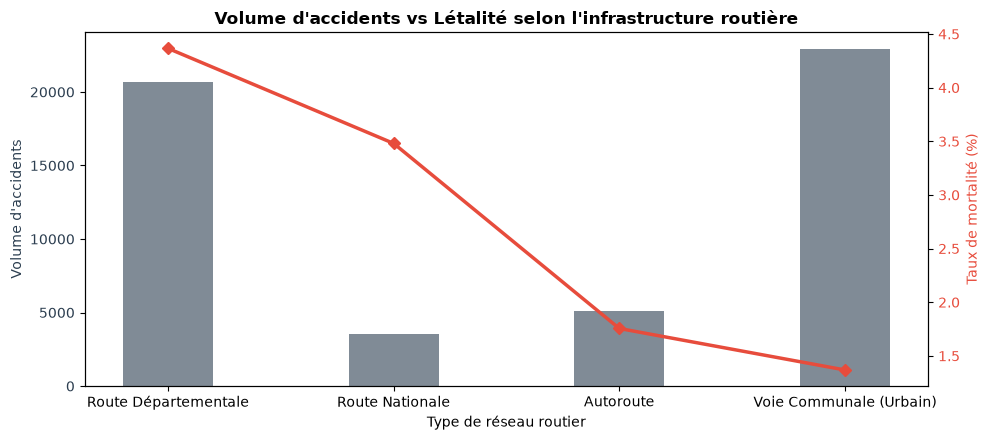

In [14]:
df_q3 = pd.DataFrame(list(db["accidents"].aggregate(pipeline_reseau_routier)))

fig, ax1 = plt.subplots(figsize=(10, 4.5))

color = "#2C3E50"
ax1.set_xlabel("Type de réseau routier")
ax1.set_ylabel("Volume d'accidents", color=color)
bars = ax1.bar(df_q3["type_route"], df_q3["nombre_accidents"], color=color, alpha=0.6, width=0.4)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "#E74C3C"
ax2.set_ylabel("Taux de mortalité (%)", color=color)
points = ax2.plot(df_q3["type_route"], df_q3["taux_mortalite_pct"], color=color, marker="D", linewidth=2.5)
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Volume d'accidents vs Létalité selon l'infrastructure routière", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

In [15]:
pipeline_sexe_conducteur = [
    {"$unwind": "$vehicules"},
    {"$unwind": "$vehicules.usagers"},
    {
        "$match": {
            "vehicules.usagers.catu": 1,
            "vehicules.usagers.sexe": {"$in": [1, 2]}
        }
    },
    {
        "$group": {
            "_id": "$vehicules.usagers.sexe",
            "total_conducteurs": {"$sum": 1},
            "conducteurs_tues": {
                "$sum": {"$cond": [{"$eq": ["$vehicules.usagers.grav", 2]}, 1, 0]}
            },
            "conducteurs_hospitalises": {
                "$sum": {"$cond": [{"$eq": ["$vehicules.usagers.grav", 3]}, 1, 0]}
            }
        }
    },
    {
        "$project": {
            "_id": 0,
            "sexe": {
                "$cond": [{"$eq": ["$_id", 1]}, "Homme", "Femme"]
            },
            "total_conducteurs": 1,
            "conducteurs_tues": 1,
            "taux_mortalite_pct": {
                "$multiply": [{"$divide": ["$conducteurs_tues", "$total_conducteurs"]}, 100]
            },
            "taux_gravite_pct": {
                "$multiply": [
                    {"$divide": [
                        {"$add": ["$conducteurs_tues", "$conducteurs_hospitalises"]},
                        "$total_conducteurs"
                    ]},
                    100
                ]
            }
        }
    }
]

/tmp/ipykernel_18956/272515817.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_18956/272515817.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


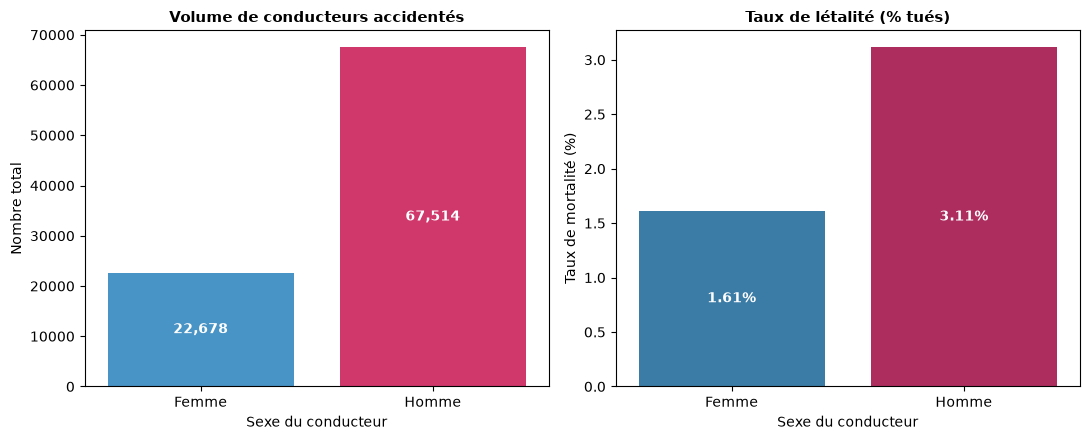

In [16]:
df_sexe = pd.DataFrame(list(db["accidents"].aggregate(pipeline_sexe_conducteur)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# 1. Volume total de conducteurs impliqués
sns.barplot(
    data=df_sexe, 
    x="sexe", 
    y="total_conducteurs", 
    ax=ax1, 
    palette=["#3498DB", "#E91E63"]
)
ax1.set_title("Volume de conducteurs accidentés", fontsize=11, fontweight="bold")
ax1.set_xlabel("Sexe du conducteur")
ax1.set_ylabel("Nombre total")

for p in ax1.patches:
    ax1.annotate(f"{int(p.get_height()):,}", 
                 (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                 ha='center', va='center', color='white', fontweight='bold')

# 2. Taux de létalité (% de décès parmi les conducteurs impliqués)
sns.barplot(
    data=df_sexe, 
    x="sexe", 
    y="taux_mortalite_pct", 
    ax=ax2, 
    palette=["#2980B9", "#C2185B"]
)
ax2.set_title("Taux de létalité (% tués)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Sexe du conducteur")
ax2.set_ylabel("Taux de mortalité (%)")

for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.2f}%", 
                 (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                 ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
client.close()